In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
path = r"C:\Users\13926\Atlantic-Project\AmesHousingClean.csv"
df = pd.read_csv(path)

In [21]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [22]:
# Encode 'Neighborhood' by the average sale price in each neighborhood
neighborhood_avg = X_train.join(y_train).groupby('Neighborhood')['SalePrice'].mean()
X_train['Neighborhood_encoded'] = X_train['Neighborhood'].map(neighborhood_avg)
X_test['Neighborhood_encoded'] = X_test['Neighborhood'].map(neighborhood_avg)
X_test['Neighborhood_encoded'] = X_test['Neighborhood_encoded'].fillna(neighborhood_avg.mean())
X_train.drop(columns='Neighborhood', inplace=True)
X_test.drop(columns='Neighborhood', inplace=True)

In [23]:
# Scale using Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Fit the data to Linear Regression and see the result
lin_regressor = LinearRegression()
lin_regressor.fit(X_train_scaled, y_train)
y_train_pred_lin = lin_regressor.predict(X_train_scaled)
y_pred_lin = lin_regressor.predict(X_test_scaled)

mae_train_lin = mean_absolute_error(y_train, y_train_pred_lin)
mae_test_lin = mean_absolute_error(y_test, y_pred_lin)
mape_train_lin = mean_absolute_percentage_error(y_train, y_train_pred_lin) * 100
mape_test_lin = mean_absolute_percentage_error(y_test, y_pred_lin) * 100
r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_pred_lin)

print(f'MAE (training): {mae_train_lin}')
print(f'MAE (testing): {mae_test_lin}')
print(f'MAPE (training): {mape_train_lin:.4f}%')
print(f'MAPE (testing): {mape_test_lin:.4f}%')
print(f'R-Squared score (training): {r2_train_lin}')
print(f'R-Squared score (testing): {r2_test_lin}')

MAE (training): 22890.214974627183
MAE (testing): 22267.899473470927
MAPE (training): 12.9244%
MAPE (testing): 12.5780%
R-Squared score (training): 0.8149869764868545
R-Squared score (testing): 0.807995996015159


In [25]:
# Fit with KNN Regressor
knn_regressor = KNeighborsRegressor()
knn_regressor.fit(X_train_scaled, y_train)
y_train_pred_knn = knn_regressor.predict(X_train_scaled)
y_pred_knn = knn_regressor.predict(X_test_scaled)

mae_test_knn_default = mean_absolute_error(y_test, y_pred_knn)
mape_test_knn_default = mean_absolute_percentage_error(y_test, y_pred_knn) * 100
r2_train_knn_default = r2_score(y_train, y_train_pred_knn)
r2_test_knn_default = r2_score(y_test, y_pred_knn)

print(f'MAE (testing): {mae_test_knn_default}')
print(f'MAPE (testing): {mape_test_knn_default:.4f}%')
print(f'R-Squared score (training): {r2_train_knn_default}')
print(f'R-Squared score (testing): {r2_test_knn_default}')

MAE (testing): 22319.16333333333
MAPE (testing): 12.2099%
R-Squared score (training): 0.9013776833612214
R-Squared score (testing): 0.7982118498864081


In [26]:
# Fine-tune KNN Regressor with grid search
param_grid_knn = {'n_neighbors': range(1, 31, 2),
                  'weights': ['uniform', 'distance'],
                  'metric': ['euclidean', 'manhattan', 'minkowski'], }
grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='neg_mean_absolute_error', n_jobs=-2)
grid_knn.fit(X_train_scaled, y_train)
print(grid_knn.best_params_)

{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}


In [27]:
# Fit the fine-tuned KNN Regressor
knn_regressor = KNeighborsRegressor(**grid_knn.best_params_)
knn_regressor.fit(X_train_scaled, y_train)
y_train_pred_knn = knn_regressor.predict(X_train_scaled)
y_pred_knn = knn_regressor.predict(X_test_scaled)

mae_train_knn_best = mean_absolute_error(y_train, y_train_pred_knn)
mae_test_knn_best = mean_absolute_error(y_test, y_pred_knn)
mape_train_knn_best = mean_absolute_percentage_error(y_train, y_train_pred_knn) * 100
mape_test_knn_best = mean_absolute_percentage_error(y_test, y_pred_knn) * 100
r2_train_knn_best = r2_score(y_train, y_train_pred_knn)
r2_test_knn_best = r2_score(y_test, y_pred_knn)

print(f'MAE (training): {mae_train_knn_best}')
print(f'MAE (testing): {mae_test_knn_best}')
print(f'MAPE (training): {mape_train_knn_best:.4f}%')
print(f'MAPE (testing): {mape_test_knn_best:.4f}%')
print(f'R-Squared score (training): {r2_train_knn_best}')
print(f'R-Squared score (testing): {r2_test_knn_best}')

MAE (training): 48.74907407407407
MAE (testing): 20378.677611517494
MAPE (training): 0.0328%
MAPE (testing): 10.9720%
R-Squared score (training): 0.9999534711920957
R-Squared score (testing): 0.8202300126484098


In [28]:
# Try with Random Forest Regressor
rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train_scaled, y_train)
y_train_pred_rf = rf_regressor.predict(X_train_scaled)
y_pred_rf = rf_regressor.predict(X_test_scaled)

mae_test_rf_default = mean_absolute_error(y_test, y_pred_rf)
mape_test_rf_default = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
r2_train_rf_default = r2_score(y_train, y_train_pred_rf)
r2_test_rf_default = r2_score(y_test, y_pred_rf)

print(f'MAE (testing): {mae_test_rf_default}')
print(f'MAPE (testing): {mape_test_rf_default:.4f}%')
print(f'R-Squared score (training): {r2_train_rf_default}')
print(f'R-Squared score (testing): {r2_test_rf_default}')

MAE (testing): 17222.783989373896
MAPE (testing): 9.7804%
R-Squared score (training): 0.9836585878303478
R-Squared score (testing): 0.8556501855565972


In [32]:
# Also do grid search on Random Forest Regressor
param_grid = {
    'n_estimators': [np.random.randint(100, 300), np.random.randint(100, 300)],
    'max_features': ['sqrt', 'auto'],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, scoring='neg_mean_absolute_error', cv=5)
grid_search.fit(X_train_scaled, y_train)
print('Best Parameters', grid_search.best_params_)


c:\Users\13926\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
360 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\13926\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\13926\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:

Best Parameters {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 215}


In [34]:
print('Best Parameters', grid_search.best_params_)

Best Parameters {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 215}


In [33]:
# Fit the fine-tuned model
rf_regressor = RandomForestRegressor(**grid_search.best_params_)
rf_regressor.fit(X_train_scaled, y_train)
y_train_pred_rf = rf_regressor.predict(X_train_scaled)
y_pred_rf = rf_regressor.predict(X_test_scaled)

mae_train_rf_best = mean_absolute_error(y_train, y_train_pred_rf)
mae_test_rf_best = mean_absolute_error(y_test, y_pred_rf)
mape_train_rf_best = mean_absolute_percentage_error(y_train, y_train_pred_rf) * 100
mape_test_rf_best = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
r2_train_rf_best = r2_score(y_train, y_train_pred_rf)
r2_test_rf_best = r2_score(y_test, y_pred_rf)

print(f'MAE (training): {mae_train_rf_best}')
print(f'MAE (testing): {mae_test_rf_best}')
print(f'MAPE (training): {mape_train_rf_best:.4f}%')
print(f'MAPE (testing): {mape_test_rf_best:.4f}%')
print(f'R-Squared score (training): {r2_train_rf_best}')
print(f'R-Squared score (testing): {r2_test_rf_best}')

MAE (training): 6208.890880278473
MAE (testing): 16609.8302698699
MAPE (training): 3.5852%
MAPE (testing): 9.4078%
R-Squared score (training): 0.9862367313291278
R-Squared score (testing): 0.872752762385848


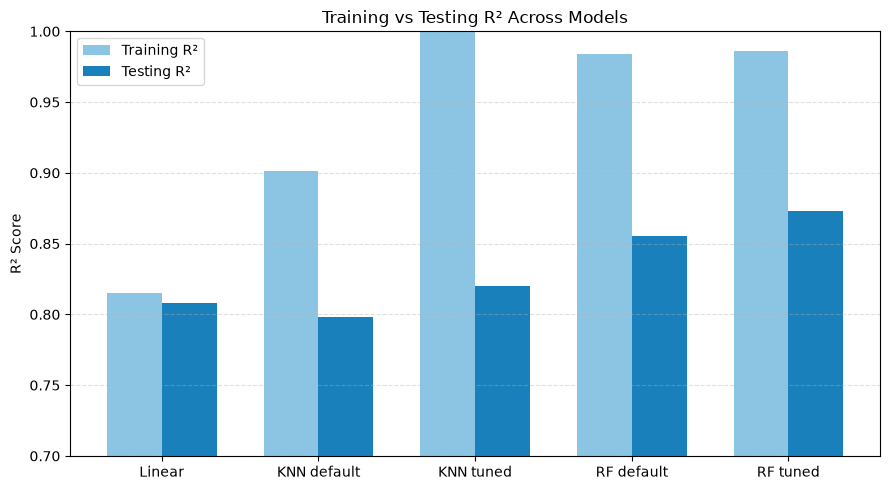

In [35]:
models = ['Linear', 'KNN default', 'KNN tuned', 'RF default', 'RF tuned']
train_r2 = [r2_train_lin, r2_train_knn_default, r2_train_knn_best, r2_train_rf_default, r2_train_rf_best]
test_r2 = [r2_test_lin, r2_test_knn_default, r2_test_knn_best, r2_test_rf_default, r2_test_rf_best]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, train_r2, width, label='Training R²', color='#8cc5e3')
ax.bar(x + width/2, test_r2, width, label='Testing R²', color='#1a80bb')
ax.set_ylabel('R² Score')
ax.set_title('Training vs Testing R² Across Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.70, 1.00)
plt.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [36]:
X_train.columns

Index(['Overall Qual', 'Lot Area', 'Living Area', 'Has Basement',
       'Garage Cars', 'Year Built', 'Total Rooms', 'Bedrooms', 'Bathrooms',
       'Fireplaces', 'Neighborhood_encoded'],
      dtype='str')

In [37]:
import joblib

In [38]:
joblib.dump(rf_regressor, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(neighborhood_avg, 'neighborhood_avg.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

def predict_new_data(new_df):
    model = joblib.load('rf_model.pkl')
    scaler = joblib.load('scaler.pkl')
    neighborhood_avg = joblib.load('neighborhood_avg.pkl')
    feature_columns = joblib.load('feature_columns.pkl')

    df = new_df.copy()

    df['Neighborhood_encoded'] = df['Neighborhood'].map(neighborhood_avg)
    df['Neighborhood_encoded'] = df['Neighborhood_encoded'].fillna(neighborhood_avg.mean())
    df = df.drop(columns='Neighborhood')

    df = df[feature_columns]

    df_scaled = scaler.transform(df)

    return model.predict(df_scaled)